In [1]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw, PandasTools
import pandas as pd
import numpy as np
import MDAnalysis as mda
import nglview as nv
import os
from openmm.app import PDBFile
import requests
from pdbfixer import PDBFixer
from vina import Vina
import useful_rdkit_utils as uru

# Testing ANNalog generation

In [2]:
n_mol_to_gen = 5
initial_SMILES = "C(C)Cc1c(C(=O)N)c(-c2ccc(C(NCc3occc3)=O)cc2)c(C(OCC)=O)c(CCc2ccc(F)cc2)n1"
gen_method = "beam"
output_file = "gen.tsv"


! annalog-generate -i "{initial_SMILES}" -n {n_mol_to_gen} -m {gen_method} -o {output_file}

[INFO] input SMILES unchanged after RDKit normalization : C(C)Cc1c(C(=O)N)c(-c2ccc(C(NCc3occc3)=O)cc2)c(C(OCC)=O)c(CCc2ccc(F)cc2)n1


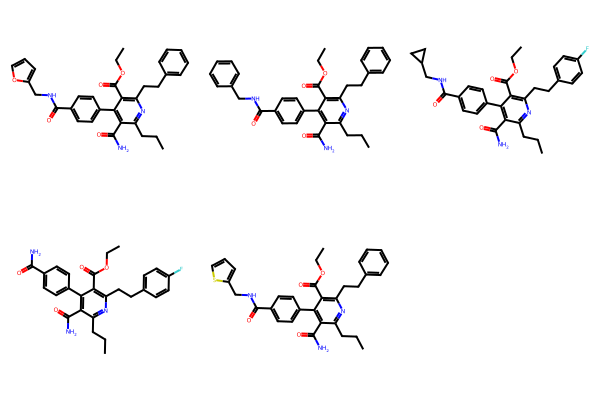

In [3]:
df = pd.read_csv("gen.tsv", sep="\t")
mols = [Chem.MolFromSmiles(s) for s in df.generated_smiles]
Draw.MolsToGridImage(mols, subImgSize=(200, 200))

# Docking preparation

## Experimental structure visualisation

In [ ]:
structure_name = "5ZTY_inactive"

input_structure_dir = "Structures"
redocking_dir = "redocking"
working_dir = os.path.join(redocking_dir, structure_name)

# defining paths for writing files to
protein_structures_dir = os.path.join(working_dir, "structures", "protein")
ligand_structures_dir = os.path.join(working_dir, "structures", "ligand")
docking_results_dir = os.path.join(working_dir, "docking_results")

# creating directories defined above
os.makedirs(protein_structures_dir, exist_ok=True)
os.makedirs(ligand_structures_dir, exist_ok=True)
os.makedirs(docking_results_dir, exist_ok=True)


pdb_file = os.path.join(input_structure_dir, f"refined_cnr2_human_{structure_name}.pdb")

u = mda.Universe(pdb_file)
view = nv.show_mdanalysis(u)
view

NGLWidget()

In [5]:
protein = u.select_atoms("protein")
ligand = u.select_atoms("not protein")
nv.show_mdanalysis(ligand)

NGLWidget()

## Prepping protein structure

### Fixing protein structure

This was based on [the workshop from the 2024 Open Force Field Initiative](https://www.youtube.com/watch?v=pwfKE6wPaMg).

In [6]:
fixer = PDBFixer(filename=pdb_file)
fixer.findMissingResidues()
fixer.findMissingAtoms()
fixer.findNonstandardResidues()
fixer.removeHeterogens(keepWater=False) # there are no water molecules in this case, but it's good to be explicit about it for future structures.
# removeHeterogens() will remove the ligand, which we will add back later.

[<Residue 360 (9JU) of chain 1>]

In [7]:
print(f"Missing residues: {fixer.missingResidues}")
print(f"Missing atoms: {fixer.missingAtoms}")
print(f"Non-standard residues: {fixer.nonstandardResidues}")
print(f"Missing terminals: {fixer.missingTerminals}")

Missing residues: {}
Missing atoms: {}
Non-standard residues: []
Missing terminals: {}


In [8]:
fixer.addMissingAtoms()
fixer.replaceNonstandardResidues()

In [9]:
fixed_structure_path = os.path.join(protein_structures_dir, f"{structure_name}_fixed.pdb")
with open(fixed_structure_path, 'w') as f:
    # Toplology, Positions, file stream, and keep chain ID's
    PDBFile.writeFile(fixer.topology, fixer.positions, f, keepIds=True)

In [10]:
fixed_prot = mda.Universe(fixed_structure_path)
nv.show_mdanalysis(fixed_prot)

NGLWidget()

In [11]:
fixed_prot

<Universe with 2785 atoms>

In [12]:
protein

<AtomGroup with 2785 atoms>

### Protonating with pdb2pqr (which uses propka under the hood)

In [13]:
! pdb2pqr -h | grep whitespace

               [--pdb-output PDB_OUTPUT] [--ligand LIGAND] [--whitespace]
  --whitespace          Insert whitespaces between atom name and residue name,


In [14]:
# setting pH to 7.4 (physiological pH), saving output additionall as pdb, and using --whitespace
# to insert whitespaces between atom name and residue name for readability
protonated_structure_name = os.path.join(protein_structures_dir, f"{structure_name}_protonated")
pH = 7.4

! pdb2pqr --pdb-output={protonated_structure_name}.pdb --pH={pH} {fixed_structure_path} {protonated_structure_name}.pqr --whitespace

INFO:PDB2PQR v3.7.1: biomolecular structure conversion software.
INFO:Please cite:  Jurrus E, et al.  Improvements to the APBS biomolecular solvation software suite.  Protein Sci 27 112-128 (2018).
INFO:Please cite:  Dolinsky TJ, et al.  PDB2PQR: expanding and upgrading automated preparation of biomolecular structures for molecular simulations. Nucleic Acids Res 35 W522-W525 (2007).
INFO:Checking and transforming input arguments.
INFO:Loading topology files.
INFO:Loading molecule: redocking/5ZTY_inactive/structures/protein/5ZTY_inactive_fixed.pdb
INFO:Setting up molecule.
INFO:Created biomolecule object with 360 residues and 2785 atoms.
INFO:Setting termini states for biomolecule chains.
INFO:Loading forcefield.
INFO:Loading hydrogen topology definitions.
INFO:This biomolecule is clean.  No repair needed.
INFO:Updating disulfide bridges.
INFO:Debumping biomolecule.
INFO:Adding hydrogens to biomolecule.
INFO:Debumping biomolecule (again).
INFO:Optimizing hydrogen bonds
INFO:Applying for

### Saving protein structure to .pdbqt

In [15]:
protein_pdbqt_path = os.path.join(protein_structures_dir, f"{structure_name}.pdbqt")

u = mda.Universe(f"{protonated_structure_name}.pqr")
u.atoms.write(protein_pdbqt_path)

# Read in the just-written PDBQT file, replace text, and write back
with open(protein_pdbqt_path, 'r') as file:
    file_content = file.read()

# Replace 'TITLE' and 'CRYST1' with 'REMARK'
file_content = file_content.replace('TITLE', 'REMARK').replace('CRYST1', 'REMARK')

# Write the modified content back to the file
with open(protein_pdbqt_path, 'w') as file:
    file.write(file_content)

/Users/dcriveanu/Documents/AI_for_Drug_Discovery_MSc/Research_Project/project_working_area/workflow_development/.pixi/envs/default/lib/python3.12/site-packages/MDAnalysis/coordinates/PDBQT.py:304: UserWarning: Supplied AtomGroup was missing the following attributes: altLocs, occupancies, tempfactors. These will be written with default values. 
  warnings.warn(


## Prepping ligand structure

Majority of the code here is taken from the [2025 Python for Cheminformatics-Driven Molecular Docking workshop (workbook 3)](https://colab.research.google.com/github/MolSSI-Education/iqb-2025/blob/main/03_Cheminfo_crash_course.ipynb#scrollTo=eGrw95tElNA-), especially downloading the ideal ligand structure.

### Downloading ideal ligand structure

The ideal ligand structure will be used for docking to the receptor, as the ligand from the PDB does not have hydrogens or bond orders assigned, whereas the ideal ligand structure has everything assigned - bond orders and hydrogens.

In [16]:
ligand_id = ligand.residues.resnames[0]
ligand_id

'9JU'

In [17]:
ideal_ligand_filename = f"{ligand_id}_ideal.sdf"
ideal_ligand_filepath = os.path.join(ligand_structures_dir, ideal_ligand_filename)

if(not os.path.exists(ideal_ligand_filepath)): # only download the ideal ligand structure if it hasn't already been downloaded
    print(f"Downloading ligand {ligand_id}...")
    ligand_url = f"https://files.rcsb.org/ligands/download/{ideal_ligand_filename}"
    ligand_request = requests.get(ligand_url)
    ligand_request.raise_for_status() # Check for errors

    with open(ideal_ligand_filepath, "w") as f:
        f.write(ligand_request.text)
    print(f"Saved ligand to {ideal_ligand_filepath}")

### Converting ideal ligand sdf to pdbqt file

In [18]:
ideal_ligand_pdbqt_filepath = os.path.join(ligand_structures_dir, f"{ligand_id}_ideal.pdbqt")
! mk_prepare_ligand.py -i {ideal_ligand_filepath} -o {ideal_ligand_pdbqt_filepath}

[RDKit] WARNING:[19:20:28] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
Input molecules processed: 1, skipped: 0
PDBQT files written: 1
PDBQT files not written due to error: 0
Input molecules with errors: 0


In [19]:
nv.show_mdanalysis(mda.Universe(ideal_ligand_pdbqt_filepath))

NGLWidget()

### Assigning correct bond orders and hydrogens to experimental ligand and aligning to experimental structure

This aligned and prepped structure will be used for comparison to the docked pose(s) later.

First, the experimental ligand needs to be in its own file to then be read by RDKit.

In [20]:
ligand_pdb_file_path = os.path.join(ligand_structures_dir, f"{ligand_id}_fromPDB.pdb")
ligand.write(ligand_pdb_file_path)

/Users/dcriveanu/Documents/AI_for_Drug_Discovery_MSc/Research_Project/project_working_area/workflow_development/.pixi/envs/default/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:885: UserWarning: Unit cell dimensions not found. CRYST1 record set to unitary values.
  warnings.warn(


Now we assigned bond orders using the ideal molecule structure as the template to the experimental ligand.

In [21]:
# Load and remove the hydrogens that we can't map anyways yet.
ideal_mol = Chem.MolFromMolFile(ideal_ligand_filepath, removeHs=True)
pose_mol = Chem.MolFromPDBFile(ligand_pdb_file_path, removeHs=True)

# Assign bond orders from the template to the pose molecule
corrected_pose = AllChem.AssignBondOrdersFromTemplate(ideal_mol, pose_mol)

# Add hydrogens back to the corrected pose
corrected_pose_with_H = Chem.AddHs(corrected_pose, addCoords=True)

# Sanity to check to make sure the molecule is right (check smiles of both)
assert Chem.MolToSmiles(corrected_pose) == Chem.MolToSmiles(ideal_mol)

# Save the corrected pose to an SDF file
ligand_corrected_pose_file = os.path.join(ligand_structures_dir, f"{ligand_id}_corrected_pose.sdf")
writer = Chem.SDWriter(ligand_corrected_pose_file) # stating where to write to
writer.write(corrected_pose_with_H) # now writing output file
writer.close()

[19:20:29] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[19:20:29] WARNING: More than one matching pattern found - picking one



In [22]:
nv.show_file(ligand_corrected_pose_file)

NGLWidget()

## Ligand preparation

In [23]:
! scrub.py -h

usage: scrub.py -o OUT_FNAME [--write_failed_mols WRITE_FAILED_MOLS]
                [--name_from_prop NAME_FROM_PROP] [--ph PH] [--skip_acidbase]
                [--skip_tautomers] [--skip_ringfix] [--skip_gen3d]
                [--keep_all_frags] [--cpu CPU] [--debug] [-h] [--wcg]
                [--charge_model {espaloma,nagl}] [--ph_low PH_LOW]
                [--ph_high PH_HIGH] [--pka_fname PKA_FNAME]
                [--tauto_fname TAUTO_FNAME] [--pka_model {rules,etr1}]
                [--max_ff_iter MAX_FF_ITER] [--skip_etkdg]
                [--num_internal_confs NUM_INTERNAL_CONFS]
                [--min_output_confs MIN_OUTPUT_CONFS]
                [--etkdg_rng_seed ETKDG_RNG_SEED]
                [--ff {uff,mmff94,mmff94s,espaloma}] [--template TEMPLATE]
                [--template_smarts TEMPLATE_SMARTS] [--ring_minimize]
                [--energy_threshold ENERGY_THRESHOLD] [--use_random_coords]
                [--num_etkdg_attempts NUM_ETKDG_ATTEMPTS]
                in

In [24]:
scrubbed_ligands_filepath = os.path.join(ligand_structures_dir, f"{ligand_id}_scrubbed.sdf")

pH_range_width = 2 # +/- this value around the specified pH will be considered when performing protonation state enumeration
pH_max = pH+pH_range_width
pH_min = pH-pH_range_width
! scrub.py {ligand_corrected_pose_file} -o {scrubbed_ligands_filepath} --ph_low {pH_min} --ph_high {pH_max}

Scrub completed.
Summary of what happened:
Input molecules supplied: 1
mols processed: 1, skipped by rdkit: 0, failed: 0
nr isomers (tautomers and acid/base conjugates): 1 (avg. 1.000 per mol)
nr conformers:  1 (avg. 1.000 per isomer, 1.000 per mol)


In [25]:
nv.show_file(scrubbed_ligands_filepath)

NGLWidget()

# Cognate docking

## Defining receptor grid

Doing one final sanity check that the prepared receptor looks ok and that the updated and cleaned cognate ligand looks good and is where it should be.

In [26]:
view = nv.show_file(f"{protonated_structure_name}.pdb")
view.add_component(ligand_corrected_pose_file)
view.add_component(ligand)
view

NGLWidget()

Also confirming that the pdbqt and pdb files have the same number of atoms. I had to check as nglview had trouble displaying the pdbqt file.

In [27]:
mda.Universe(protein_pdbqt_path)

<Universe with 5638 atoms>

In [28]:
mda.Universe(f"{protonated_structure_name}.pdb")

<Universe with 5638 atoms>

I will use MDAnalysis to get the centroid and box dimensions. RDKit can also be used for this using the corrected pose .sdf file I made, but it's less straightforward.

In [29]:
box_centre = ligand.center_of_geometry()
box_centre

array([  9.09345159,  -0.16790321, -55.72312878])

I will define the receptor grid very simply - taking the dimensions of the bound ligand and adding a buffer in each direction of 5 Angstrom.

In [30]:
buffer = 5 # in Angstroms, to add to the box dimensions to ensure the ligand fits comfortably within the box
box_dimensions = np.ceil(ligand.positions.max(axis=0) - ligand.positions.min(axis=0)) + buffer # np.ceil is used to round up the dimensions to the larger nearest integer for ease of reporting size.
print(f"Box dimensions: {box_dimensions}")

Box dimensions: [13. 16. 15.]


Vina expects lists, not numpy arrays, so here I convert the above arrays to lists.

In [31]:
box_centre = box_centre.tolist()
box_dimensions = box_dimensions.tolist()

Now I want to visualise the receptor grid to confirm that it's in the right place and big enough.

In [32]:
def add_receptor_grid_to_vis(view, box_centre, box_dimensions):
    # Code taken and adapted from https://youtu.be/pwfKE6wPaMg?si=MW0QejPGrl359mlV - Protein Preparation in Jupyter - 2024 Mini-Workshop,
    # Open Force field Initiative
    """Add a receptor grid to the visualization.

    Args:
        view (nglview.NGLWidget): The NGL widget to add the grid to
        box_centre (list): The centre of the grid
        box_dimensions (list): The dimensions of the grid

    Returns:
        nglview.NGLWidget: The updated NGL widget
    """

    x = [box_centre[0] - box_dimensions[0]/2, box_centre[0] + box_dimensions[0]/2]
    y = [box_centre[1] - box_dimensions[1]/2, box_centre[1] + box_dimensions[1]/2]
    z = [box_centre[2] - box_dimensions[2]/2, box_centre[2] + box_dimensions[2]/2]
    color = [1, 0, 0.7]
    radius = 0.5
    args = [color, radius]
        
    view.shape.add_arrow([x[0], y[0], z[0]], [x[0], y[0], z[1]], *args)
    view.shape.add_arrow([x[0], y[0], z[0]], [x[0], y[1], z[0]], *args)
    view.shape.add_arrow([x[0], y[0], z[0]], [x[1], y[0], z[0]], *args)
        
    view.shape.add_arrow([x[1], y[1], z[1]], [x[0], y[1], z[1]], *args)
    view.shape.add_arrow([x[1], y[1], z[1]], [x[1], y[0], z[1]], *args)
    view.shape.add_arrow([x[1], y[1], z[1]], [x[1], y[1], z[0]], *args)

    view.shape.add_arrow([x[1], y[0], z[1]], [x[0], y[0], z[1]], *args)
    view.shape.add_arrow([x[0], y[1], z[1]], [x[0], y[0], z[1]], *args)
    
    view.shape.add_arrow([x[0], y[1], z[1]], [x[0], y[1], z[0]], *args)
    view.shape.add_arrow([x[1], y[1], z[0]], [x[0], y[1], z[0]], *args)
    
    view.shape.add_arrow([x[1], y[1], z[0]], [x[1], y[0], z[0]], *args)
    view.shape.add_arrow([x[1], y[0], z[1]], [x[1], y[0], z[0]], *args)
    
    return view

In [33]:
view = nv.NGLWidget()

view = nv.show_file(f"{protonated_structure_name}.pdb")
# view.clear_representations()
# view.add_representation("surface")
view.add_component(ligand_corrected_pose_file)

view = add_receptor_grid_to_vis(view, box_centre, box_dimensions)
view

NGLWidget()

## Actually docking now

In [34]:
v=Vina(sf_name="vina") # using the default vina scoring function

I am using the default values (but setting the explicitly) for the docking process as this paper by [R. Agarwal and J. C. Smith, Mol. Inform. 2023](https://pubmed.ncbi.nlm.nih.gov/36262028/) confirmed that an exhaustiveness of 8 is sufficient.

#### NOTE: I just realised that Autodock Vina does not support AT ALL multi-ligand files, like the multi-ligand .sdf files that Scrubber produces. To use Scrubber with Vina, I would need to convert each structure in that .sdf into individual .pdbqt files, which would be absurd. Instead, I could use a different docking engine like SMINA which can support these multi-ligand files natively.

I think the intention behind using Vina was to not overcomplicate things, like with Scrubber, and literally just dock each structure as it comes out from ANNalog into the target protein - no enumeration of protonation states or tautomers.

In [35]:
nv.show_file(ideal_ligand_pdbqt_filepath)


NGLWidget()

In [36]:
exhaustiveness = 16 # doubled from the default of 8
n_poses = 20

v.set_receptor(protein_pdbqt_path)
v.set_ligand_from_file(ideal_ligand_pdbqt_filepath)
v.compute_vina_maps(center=box_centre, box_size=box_dimensions)
v.dock(exhaustiveness=exhaustiveness, n_poses=n_poses)

Computing Vina grid ... done.
Performing docking (random seed: -2050793883) ... 
0%   10   20   30   40   50   60   70   80   90   100%
|----|----|----|----|----|----|----|----|----|----|
***************************************************

mode |   affinity | dist from best mode
     | (kcal/mol) | rmsd l.b.| rmsd u.b.
-----+------------+----------+----------
   1       -10.82          0          0
   2       -10.76    0.08931      1.324
   3       -10.73     0.1584       1.64
   4       -9.551      2.666      8.832
   5       -9.415      2.494      8.711
   6        -9.41      2.396      8.538
   7       -9.317      2.423      8.494
   8       -8.903      2.207      8.567
   9       -8.576      2.467      8.775
  10       -7.245      1.742      3.015
  11       -7.087      1.896      4.494
  12       -7.083      1.594      4.544
  13       -7.058      2.279       8.66
  14       -7.054      1.608      4.504
  15       -6.804       1.82      8.002
  16       -6.736      2.023      4.1

In [37]:
docking_results_poses_path = os.path.join(docking_results_dir, f"{ligand_id}.pdbqt")

v.write_poses(docking_results_poses_path, n_poses=9, overwrite=True)
# note: even though n_poses=9 is specified, less poses can still be written if the later poses have an energy higher than the lowest energy poses
# by 3 or more (by default) - this energy range is specified by the `energy_range` keyword.

In [38]:
# These are the columns for the types of energies according to AutoDock Vina docs.
column_names = ["total", "inter", "intra", "torsions", "intra best pose"]

df = pd.DataFrame(v.energies(), columns=column_names)
df.head()

,total,inter,intra,torsions,intra best pose
0,-10.822,-16.200,-0.395,5.378,-0.395
1,-10.760,-16.180,-0.322,5.347,-0.395
2,-10.728,-16.121,-0.333,5.331,-0.395
3,-9.551,-14.544,-0.147,4.746,-0.395
4,-9.415,-14.167,-0.322,4.679,-0.395


In [39]:
# Save the calculated energies from docking to a CSV file
docking_energies_path = os.path.join(docking_results_dir, f"{ligand_id}_energies.csv")
df.to_csv(docking_energies_path, index=False)

In [40]:
! mk_export.py {docking_results_poses_path} -s {docking_results_dir}/{ligand_id}.sdf

In [41]:
# Read multiple molecules from the SDF file
suppl = Chem.SDMolSupplier(os.path.join(docking_results_dir, f"{ligand_id}.sdf"))
docking_poses = [mol for mol in suppl if mol is not None]
print(f"Number of poses read: {len(docking_poses)}")

crystallographic_pose = Chem.MolFromMolFile(ligand_corrected_pose_file) #MolFromMolFile just returns one molecule, which is what we want for the crystallographic pose.

# Create NGLView widget
view = nv.NGLWidget()

# Add crystallographic pose in red
crys_pose_component = view.add_component(crystallographic_pose)
crys_pose_component.clear_representations()
crys_pose_component.add_representation("ball+stick", color="red", colorScheme="whiteCarbon")

# Add docked pose in blue
dock_pose_component = view.add_component(docking_poses[0])
dock_pose_component.clear_representations()
dock_pose_component.add_representation("ball+stick", color="blue", colorScheme="whiteCarbon")

view

Number of poses read: 9


NGLWidget()

In [42]:
def get_rmsd_to_cognate(cognate, docked_poses:list):
    rmsd_array = []
    for pose in docked_poses:
        _, rmsd = uru.mcs_rmsd(cognate, pose)
        rmsd_array.append(rmsd)
    rmsd_array = np.array(rmsd_array)
    return rmsd_array

rmsd_array = get_rmsd_to_cognate(crystallographic_pose, docking_poses)

rmsd_df = df.copy().head(len(docking_poses))[["total"]]
rmsd_df.rename(columns={"total": "vina_energy"}, inplace=True)
rmsd_df["rmsd"] = rmsd_array
rmsd_df.to_csv(os.path.join(docking_results_dir, f"{ligand_id}_energies_and_cognate_rmsd.csv"), index=False)
rmsd_df

,vina_energy,rmsd
0,-10.822,1.391086
1,-10.760,1.367863
2,-10.728,1.616897
3,-9.551,8.931603
4,-9.415,8.712398
5,-9.410,8.588383
6,-9.317,8.597897
7,-8.903,8.557327
8,-8.576,8.865061


I want to confirm programmatically if any of the docked poses have an RMSD less than 2 Angstrom with respect to the cognate pose.

In [43]:
np.any(np.array(rmsd_array) < 2)

np.True_